# IMPORT STATEMENTS

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# PATHS AND VARIABLES

In [2]:
TRAIN_DATA_DIR = "../../data/combined-dataset-16-class/train"
TEST_DATA_DIR = "../../data/combined-dataset-16-class/test"
train_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR)
test_dataset = datasets.ImageFolder(root=TEST_DATA_DIR)
sns.set_theme(style="whitegrid")

# TRAIN CLASSES AND COUNT

In [3]:
train_classes = train_dataset.classes
print(f"Total Classes: {len(train_classes)}")
print(f"Total Training Images: {len(train_dataset)}")

Total Classes: 16
Total Training Images: 2459


In [4]:
train_class_counts = {class_name: 0 for class_name in train_classes}
for _, class_idx in train_dataset.samples:
    train_class_counts[train_classes[class_idx]] += 1

df_counts_train = pd.DataFrame(list(train_class_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts_train = df_counts_train.sort_values(by='Image Count', ascending=False)
df_counts_train

,Disease Class,Image Count
7,Potato Leaf Blight,263
5,Corn Leaf Blight,258
15,Tomato Septoria Leaf Spot,215
1,Apple Rust Leaf,197
2,Apple Scab leaf,190
6,Corn Rust Leaf,186
12,Tomato Leaf Late Blight,167
10,Tomato Leaf Bacterial Spot,163
11,Tomato Leaf Early Blight,159
14,Tomato Mold Leaf,149


/tmp/ipykernel_20712/1865179398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df_counts_train, palette='viridis')


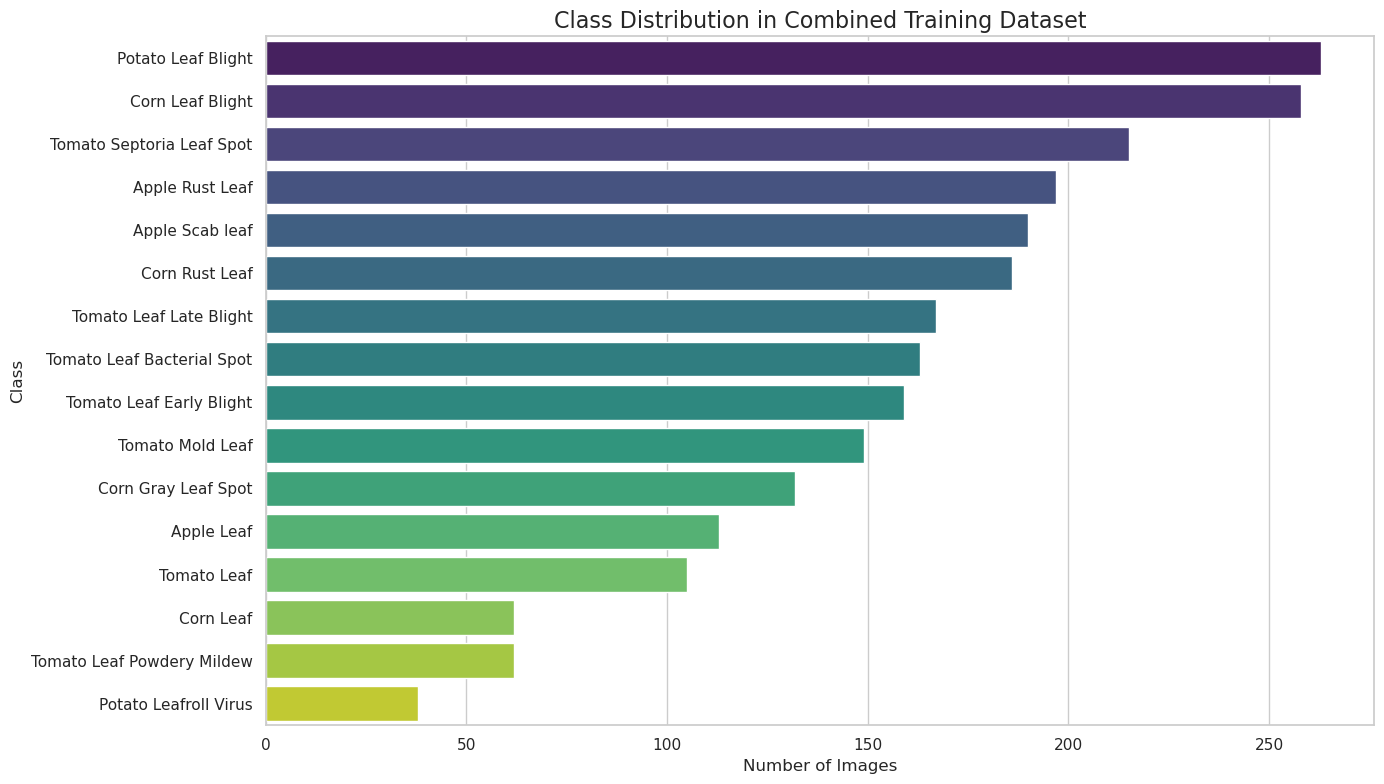

In [5]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts_train, palette='viridis')
plt.title('Class Distribution in Combined Training Dataset', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.tight_layout()
plt.show()

# TEST CLASSES AND COUNT

In [6]:
test_classes = test_dataset.classes
print(f"Total Classes: {len(test_classes)}")
print(f"Total Testing Images: {len(test_dataset)}")

Total Classes: 16
Total Testing Images: 322


In [7]:
test_class_counts = {class_name: 0 for class_name in test_classes}
for _, class_idx in test_dataset.samples:
    test_class_counts[test_classes[class_idx]] += 1

df_counts_test = pd.DataFrame(list(test_class_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts_test = df_counts_test.sort_values(by='Image Count', ascending=False)
df_counts_test

,Disease Class,Image Count
1,Apple Rust Leaf,32
2,Apple Scab leaf,32
7,Potato Leaf Blight,27
5,Corn Leaf Blight,23
15,Tomato Septoria Leaf Spot,22
6,Corn Rust Leaf,21
12,Tomato Leaf Late Blight,21
0,Apple Leaf,20
11,Tomato Leaf Early Blight,20
10,Tomato Leaf Bacterial Spot,20


/tmp/ipykernel_20712/757096600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df_counts_test, palette='viridis')


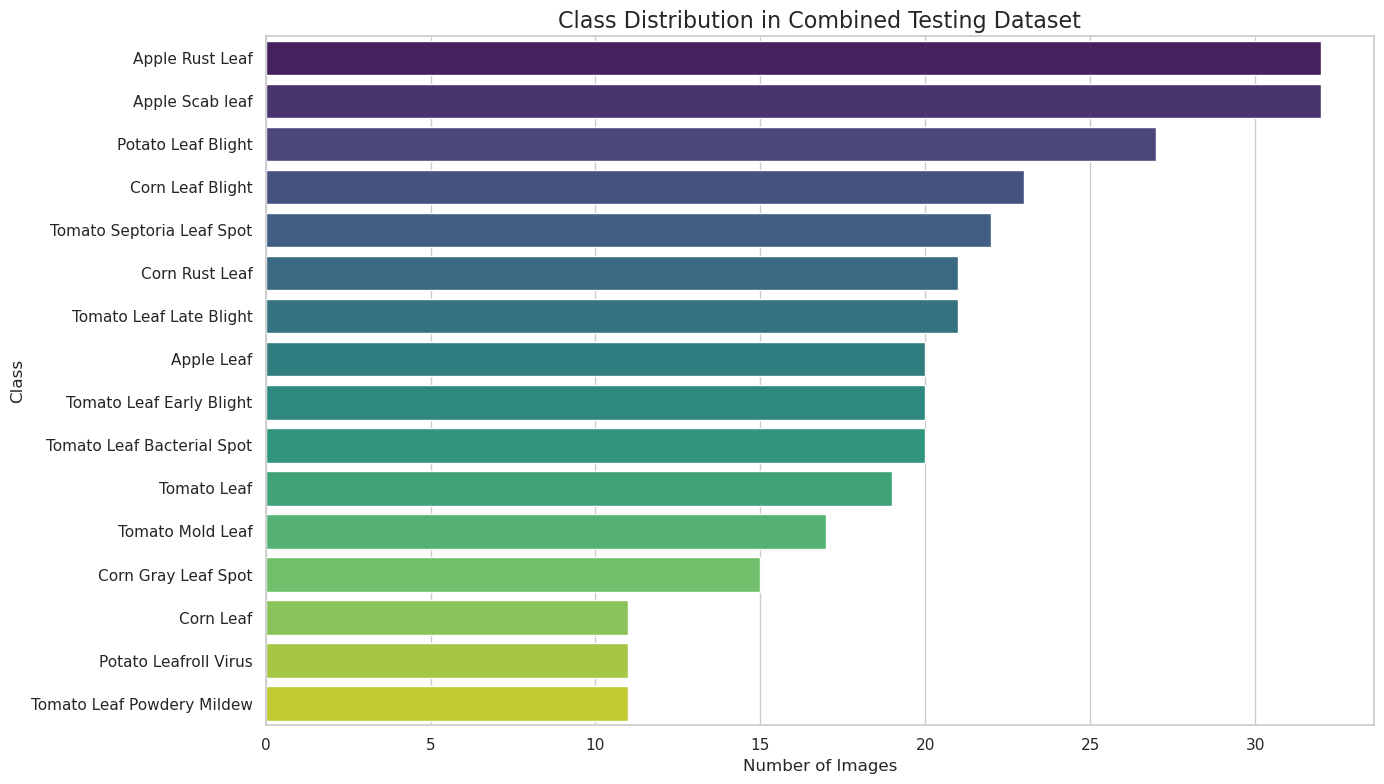

In [8]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts_test, palette='viridis')
plt.title('Class Distribution in Combined Testing Dataset', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.tight_layout()
plt.show()

# CALCULATE STANDARD INVERSE CLASS WEIGHTS

In [9]:
# Formula: total_samples / (num_classes * count_for_class)
total_samples = len(train_dataset)
num_classes = len(train_classes)

weights = []
for class_name in train_classes:
    count = train_class_counts[class_name]
    weight = total_samples / (num_classes * count)
    weights.append(weight)

In [10]:
class_weights_tensor = torch.FloatTensor(weights)
weight_dict = {class_name: float(weight) for class_name, weight in zip(train_classes, weights)}
print(f"class_weights = {weight_dict}")

class_weights = {'Apple Leaf': 1.3600663716814159, 'Apple Rust Leaf': 0.7801395939086294, 'Apple Scab leaf': 0.8088815789473685, 'Corn Gray Leaf Spot': 1.1642992424242424, 'Corn Leaf': 2.4788306451612905, 'Corn Leaf Blight': 0.595687984496124, 'Corn Rust Leaf': 0.8262768817204301, 'Potato Leaf Blight': 0.5843631178707225, 'Potato Leafroll Virus': 4.0444078947368425, 'Tomato Leaf': 1.463690476190476, 'Tomato Leaf Bacterial Spot': 0.9428680981595092, 'Tomato Leaf Early Blight': 0.9665880503144654, 'Tomato Leaf Late Blight': 0.9202844311377245, 'Tomato Leaf Powdery Mildew': 2.4788306451612905, 'Tomato Mold Leaf': 1.0314597315436242, 'Tomato Septoria Leaf Spot': 0.7148255813953488}


In [11]:
weights_path = Path(TRAIN_DATA_DIR).parent / "class_weights.json"
with open(weights_path, 'w') as f:
    json.dump(weight_dict, f, indent=4)
print(f"Weights successfully saved to: {weights_path}")

Weights successfully saved to: ../../data/combined-dataset-16-class/class_weights.json


# GAUSSIAN NOISE

In [12]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

# DEFINE TRANSFORMS

In [13]:
clean_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

noisy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.05)
])

# TRAIN IMAGE

In [14]:
sample_path_train = train_dataset.samples[0][0]
train_img = Image.open(sample_path_train).convert('RGB')

In [15]:
clean_img_train = clean_transform(train_img).permute(1, 2, 0).numpy()
noisy_img_train = noisy_transform(train_img).permute(1, 2, 0).numpy()
noisy_img_train = np.clip(noisy_img_train, 0, 1)

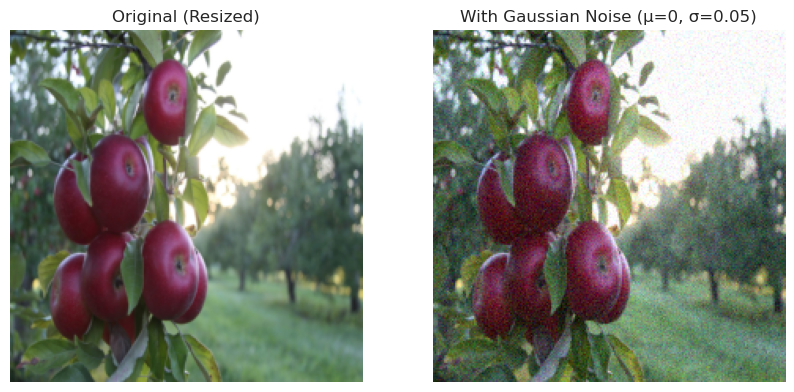

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(clean_img_train)
axes[0].set_title("Original (Resized)")
axes[0].axis('off')

axes[1].imshow(noisy_img_train)
axes[1].set_title("With Gaussian Noise (\u03BC=0, \u03C3=0.05)")
axes[1].axis('off')

plt.show()

# TEST IMAGE

In [17]:
sample_path_test = test_dataset.samples[0][0]
test_img = Image.open(sample_path_test).convert('RGB')

In [18]:
clean_img_test = clean_transform(test_img).permute(1, 2, 0).numpy()
noisy_img_test = noisy_transform(test_img).permute(1, 2, 0).numpy()
noisy_img_test = np.clip(noisy_img_test, 0, 1)

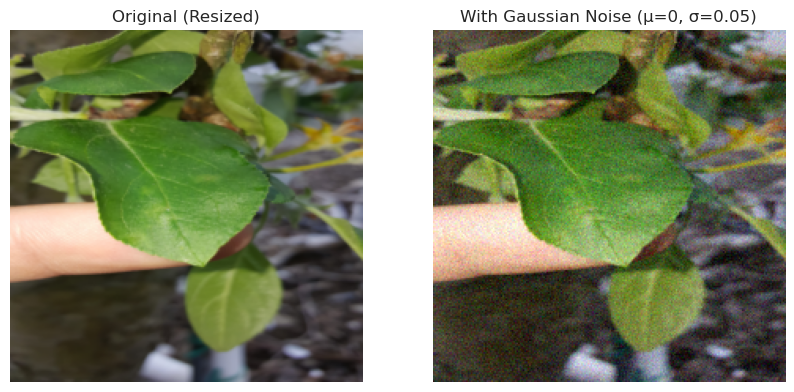

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(clean_img_test)
axes[0].set_title("Original (Resized)")
axes[0].axis('off')

axes[1].imshow(noisy_img_test)
axes[1].set_title("With Gaussian Noise (\u03BC=0, \u03C3=0.05)")
axes[1].axis('off')

plt.show()